In [3]:
%autoreload 2

In [96]:
%reload_ext autoreload

import sys
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 13})

__BOUT FINDER__

In [100]:
path = f'C://Data//imaging//260325_frmd7//fish12//'
#if imaging fish
fish = Gafftopsail(path, sequence  = 1, filelist = ['stimulus', 'eye', 'processed_eye'])

In [16]:
fish.saccade_df

,cont_tuples_eyeindex,cont_tuples_realtime_s,e0_change,e1_change,eye_stimuli,eye_realstimuli,eye_fromstart_s,e_conv_change,e_conj_change
0,"(65, 95)","(-0.525593, -0.13563499999999995)",-2.891313,-1.369537,NaN,NaN,NaN,1.521776,-4.260850
1,"(735, 803)","(8.137234, 9.013891)",-11.713461,-25.560619,right,stationary,8.137234,-13.847159,-37.274080
2,"(1876, 1945)","(22.838908, 23.705592)",-11.533687,-26.394540,right,right,22.838908,-14.860853,-37.928226
3,"(2410, 2477)","(29.824224, 30.667966)",-8.520294,-24.839088,right,right,29.824224,-16.318794,-33.359382
4,"(2658, 2715)","(33.011698, 33.734764)",-2.437856,-9.990120,right,right,33.011698,-7.552264,-12.427976
...,...,...,...,...,...,...,...,...,...
105,"(97558, 97639)","(1440.990469, 1442.267053)",14.325438,16.653984,pause,stationary,239.721765,2.328546,30.979422
106,"(97977, 98028)","(1447.675585, 1448.452506)",4.016891,2.231798,pause,stationary,246.406881,-1.785093,6.248689
107,"(99207, 99273)","(1466.674765, 1467.663119)",-8.038686,-23.248274,pause,stationary,265.406061,-15.209588,-31.286959
108,"(100322, 100381)","(1483.875753, 1484.853138)",11.053292,2.959588,pause,stationary,282.607049,-8.093704,14.012880


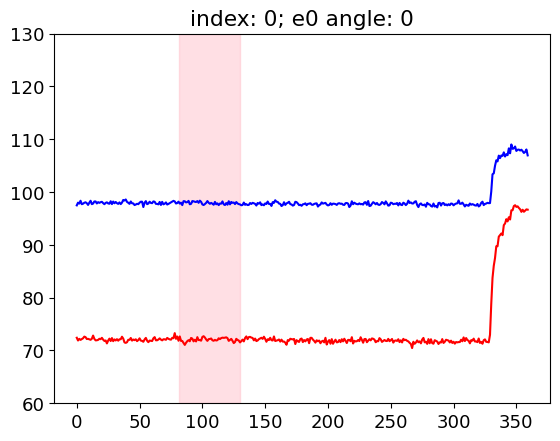

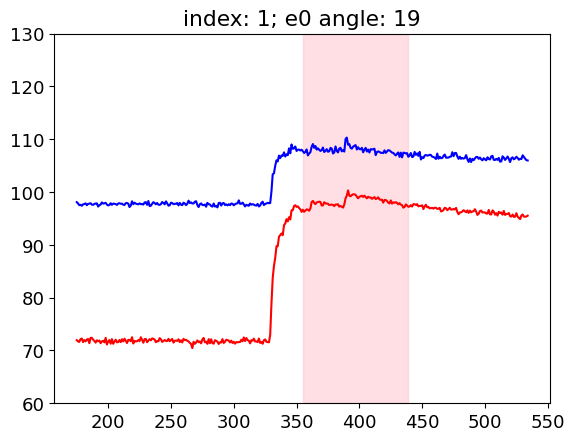

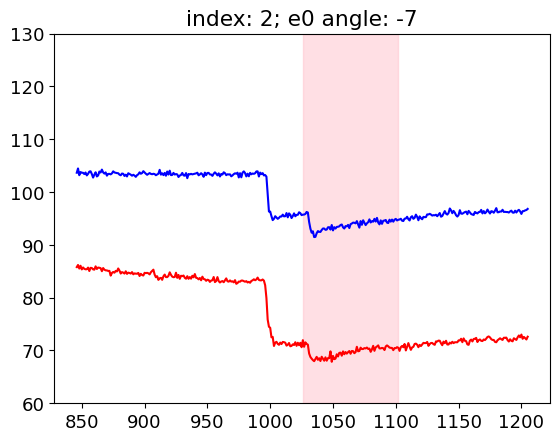

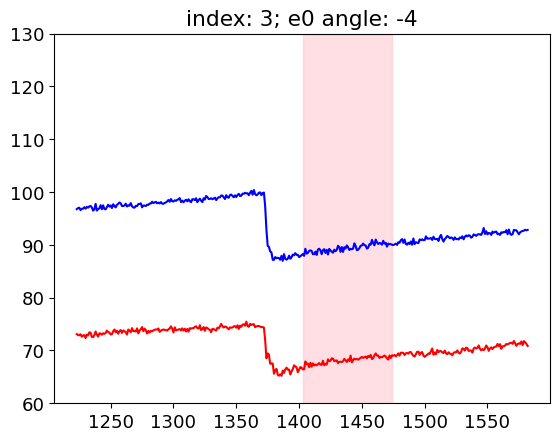

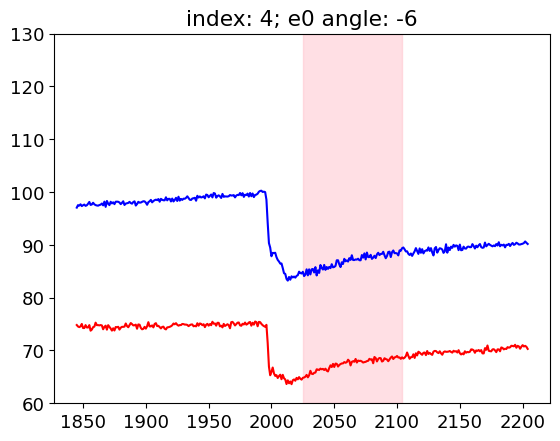

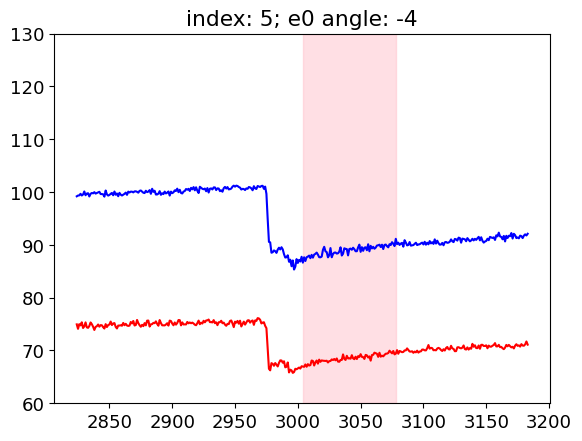

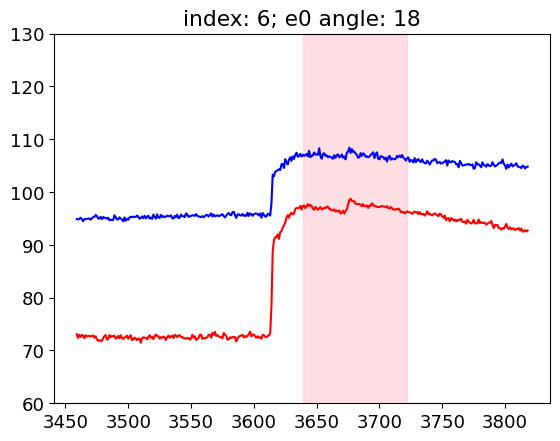

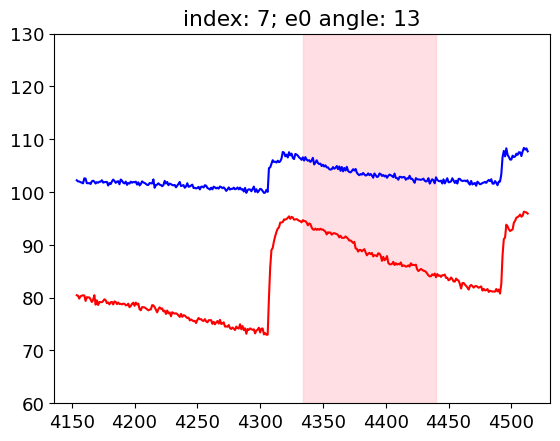

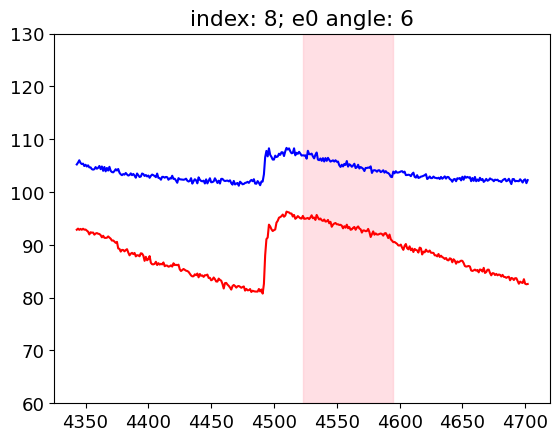

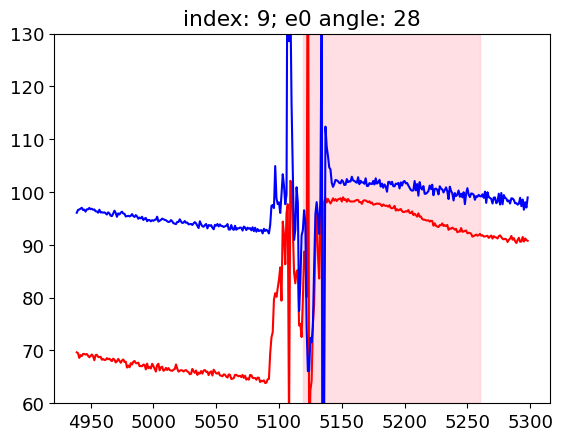

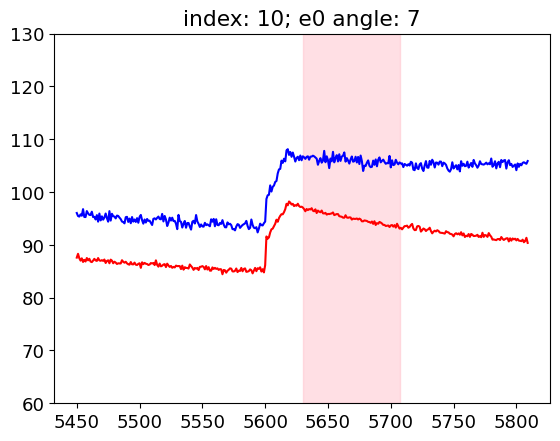

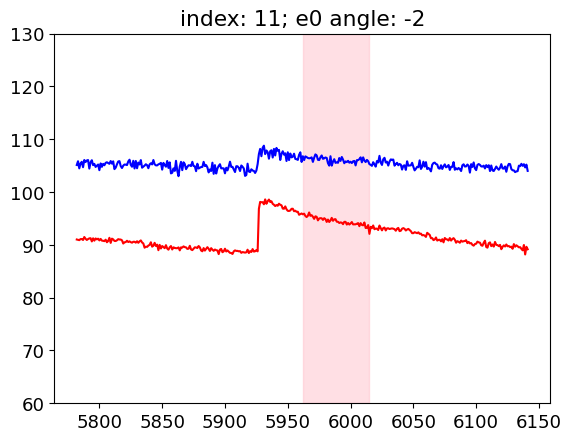

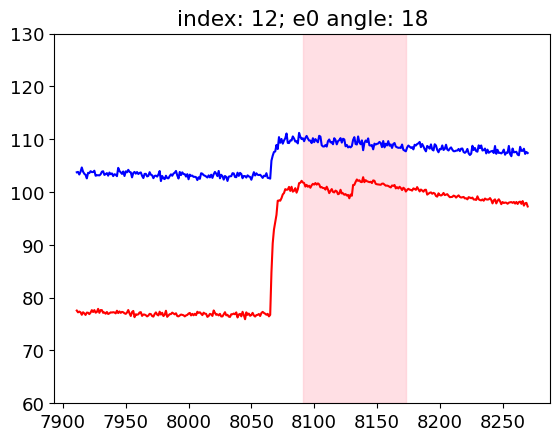

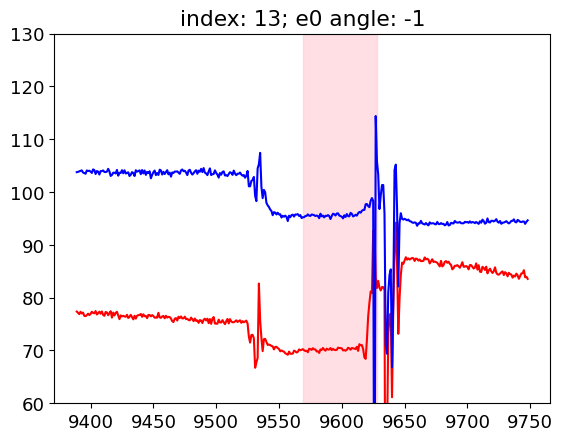

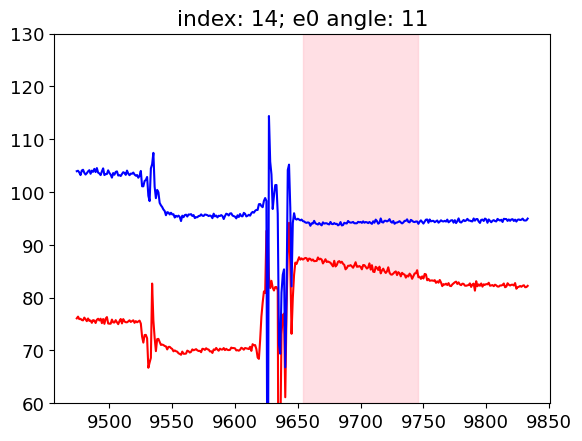

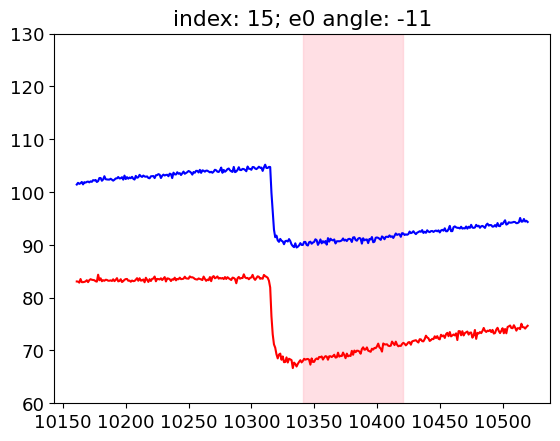

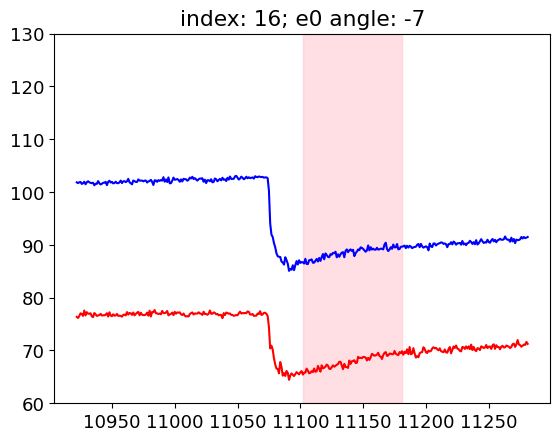

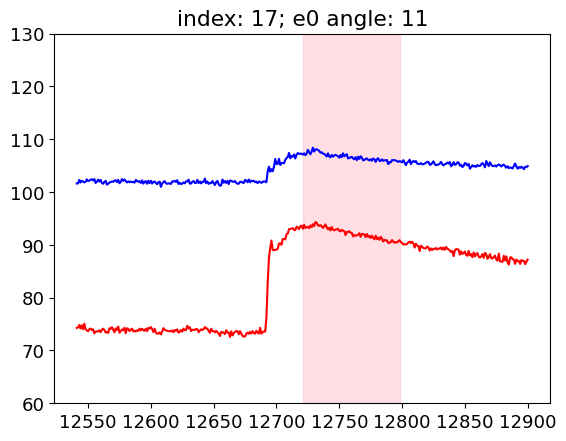

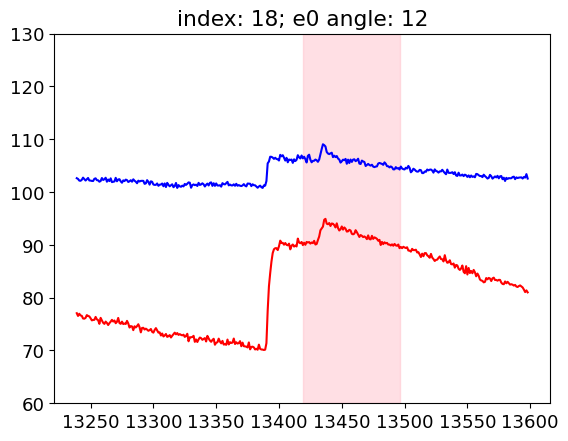

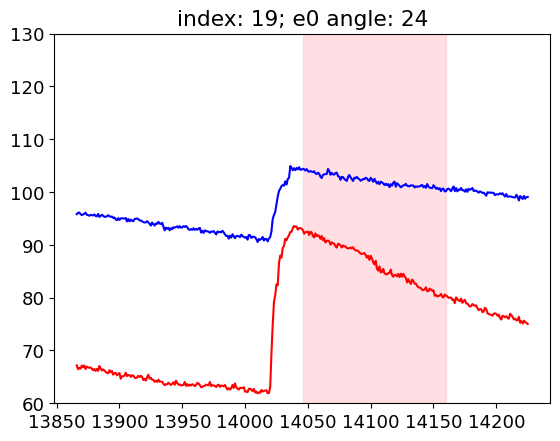

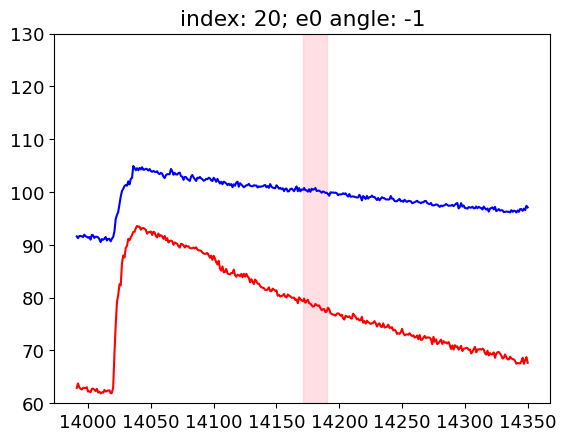

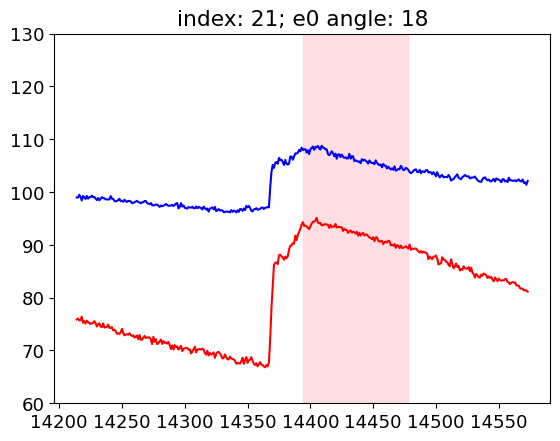

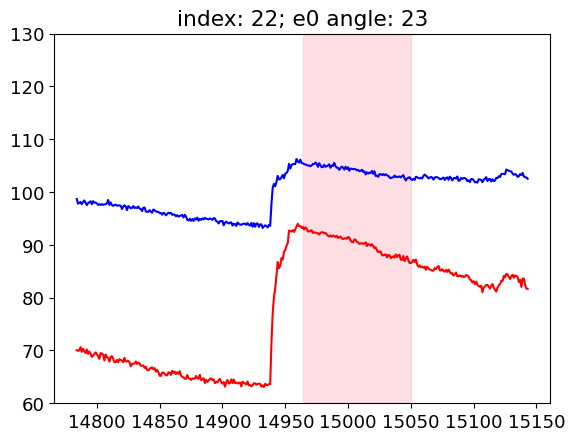

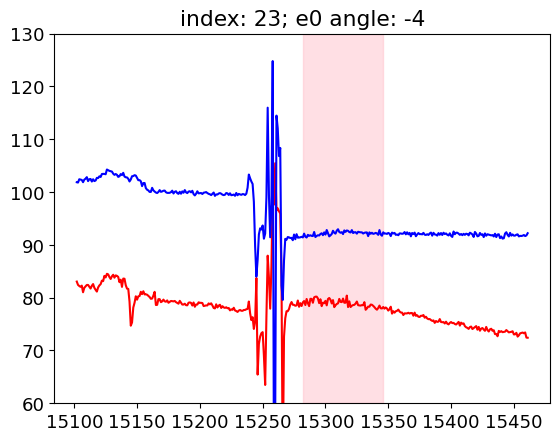

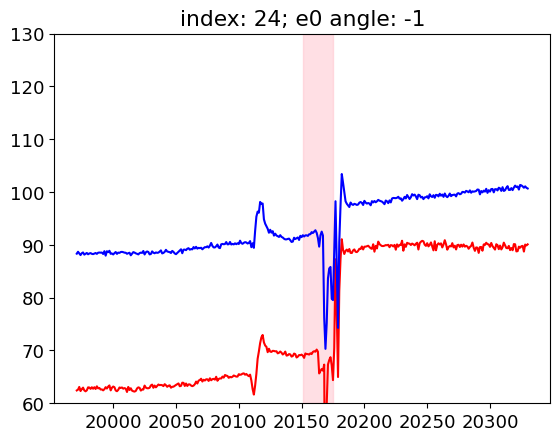

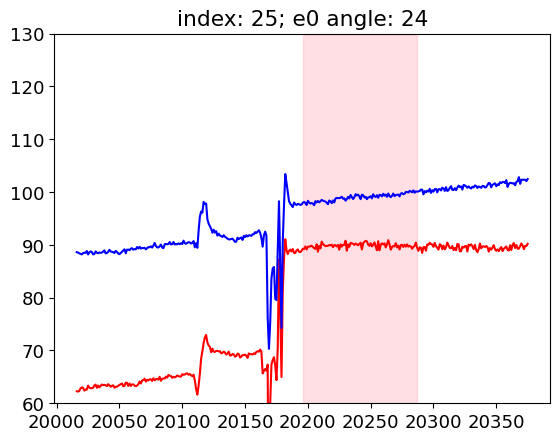

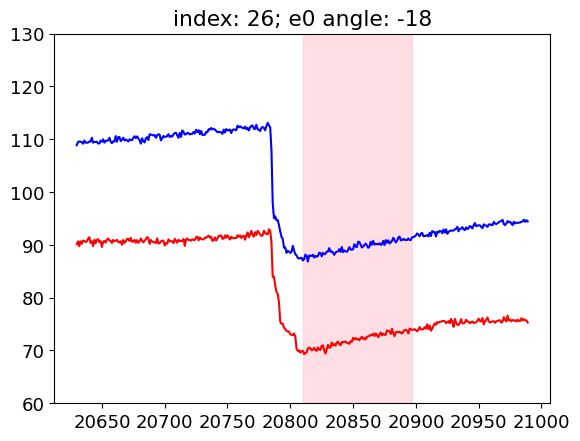

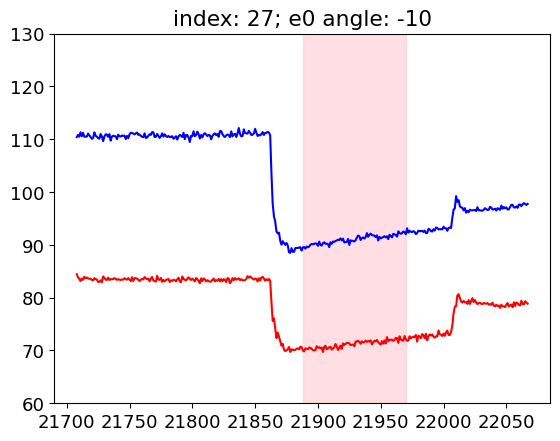

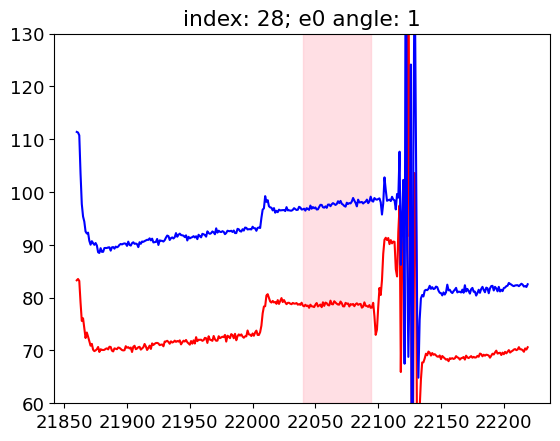

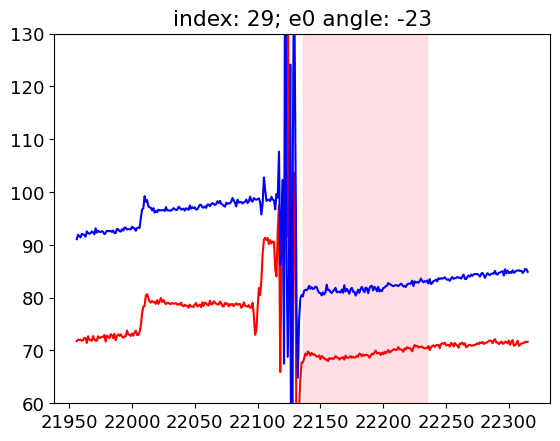

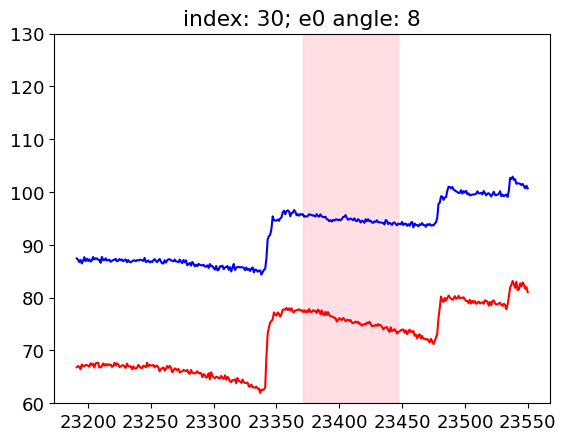

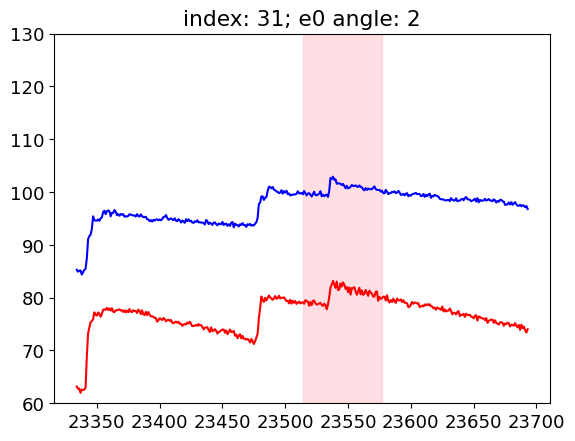

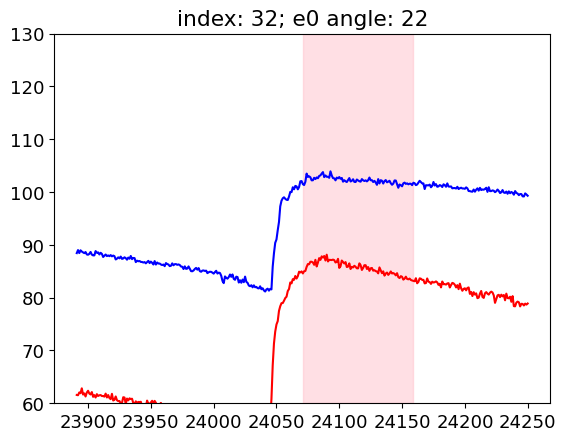

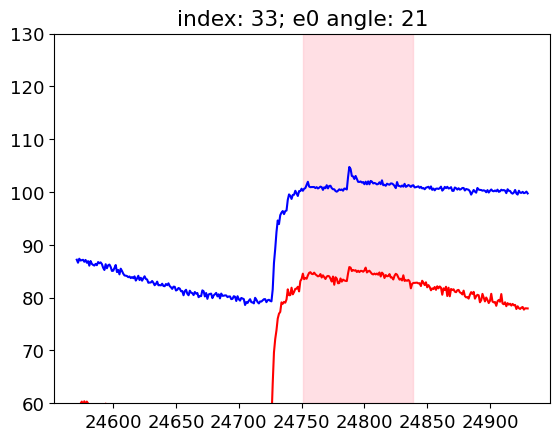

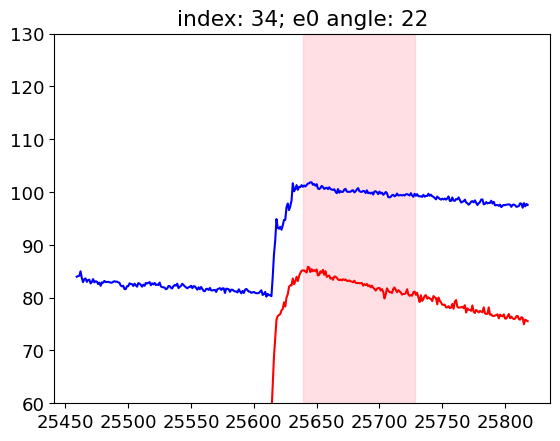

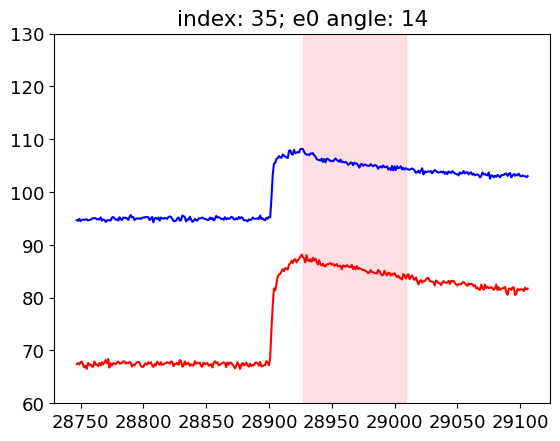

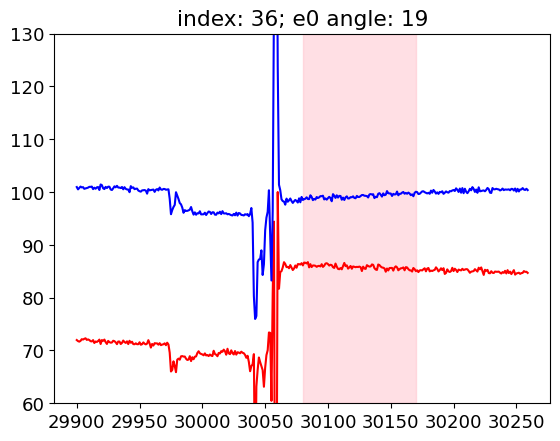

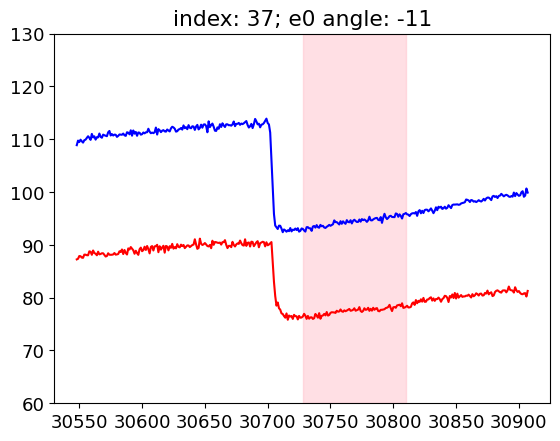

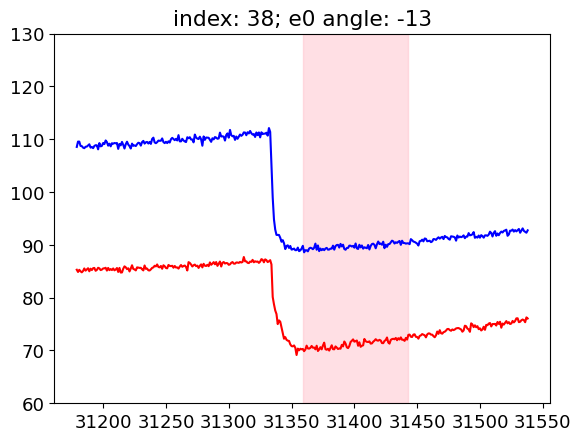

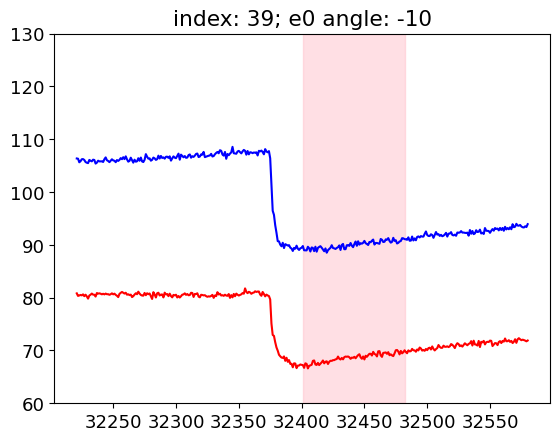

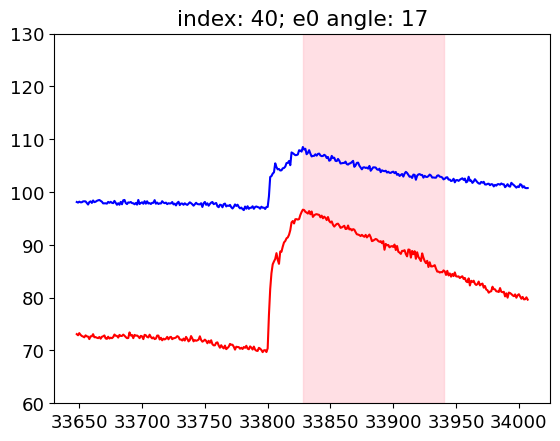

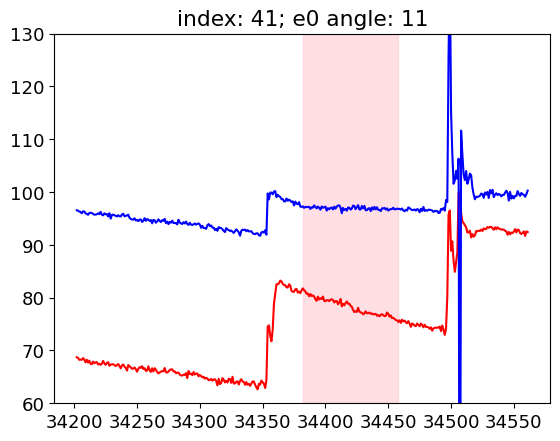

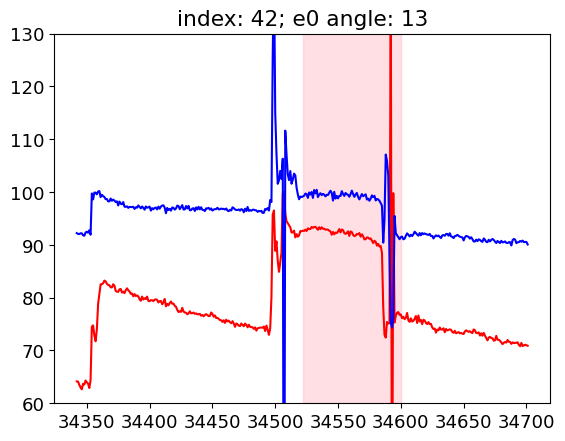

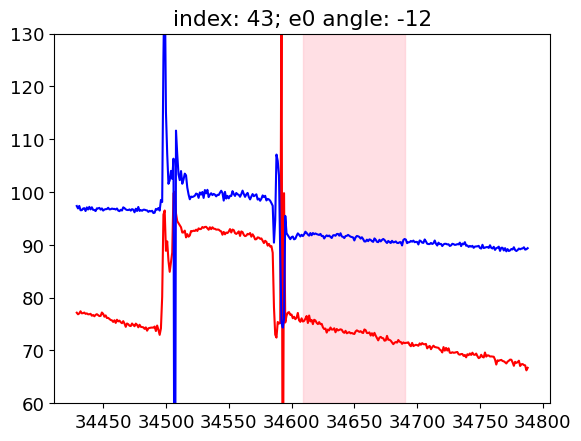

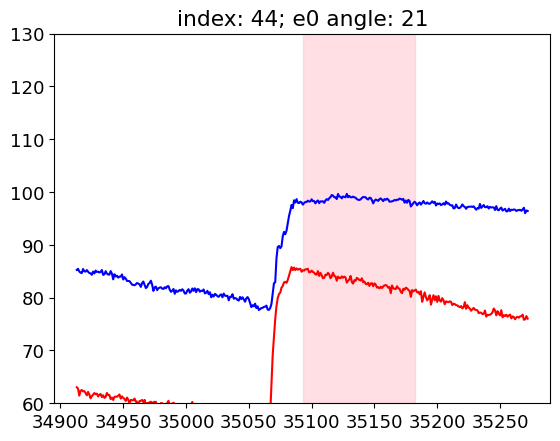

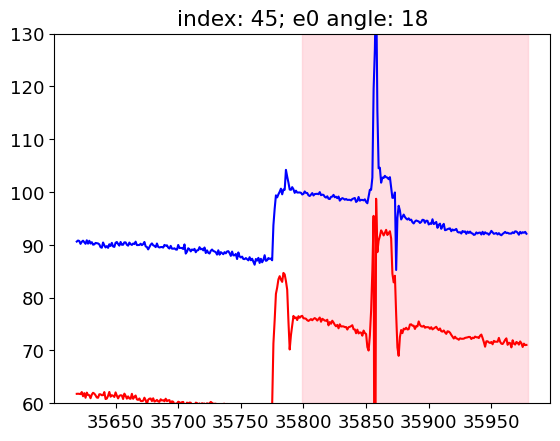

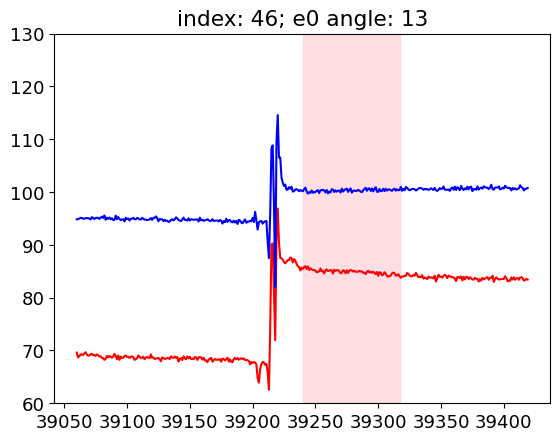

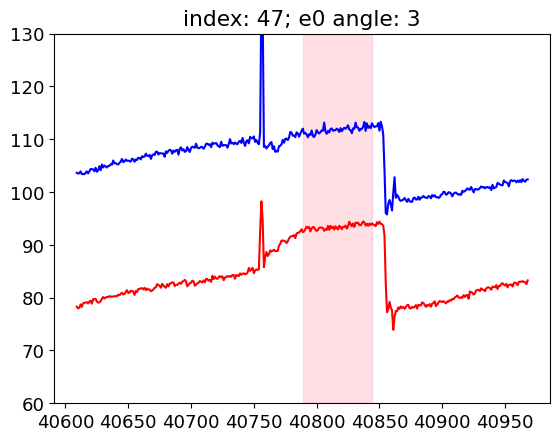

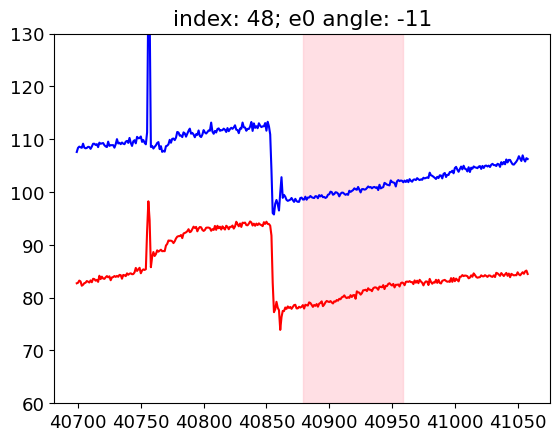

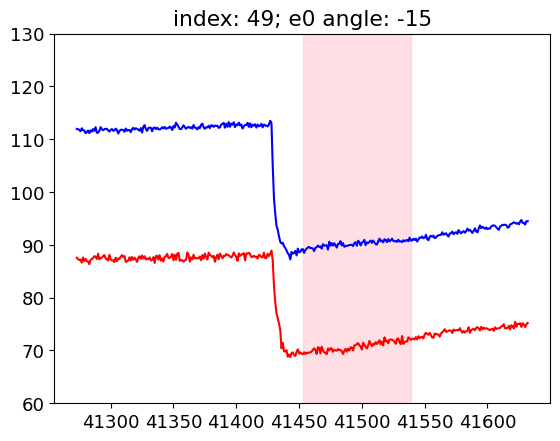

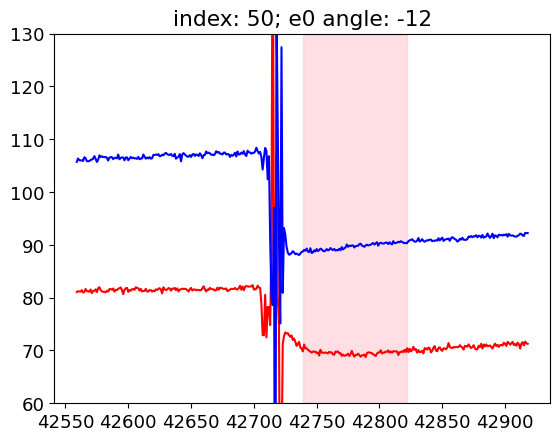

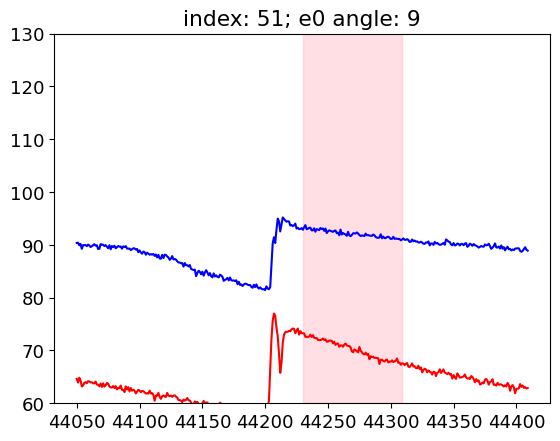

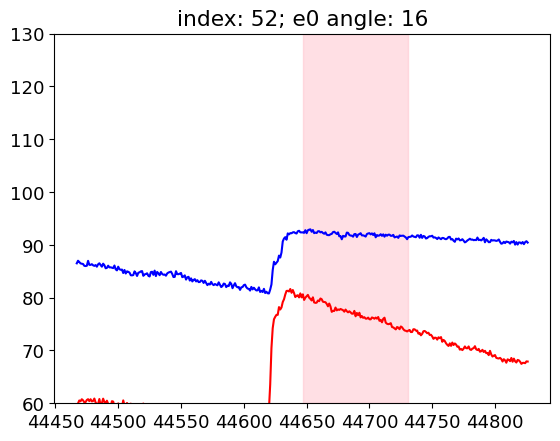

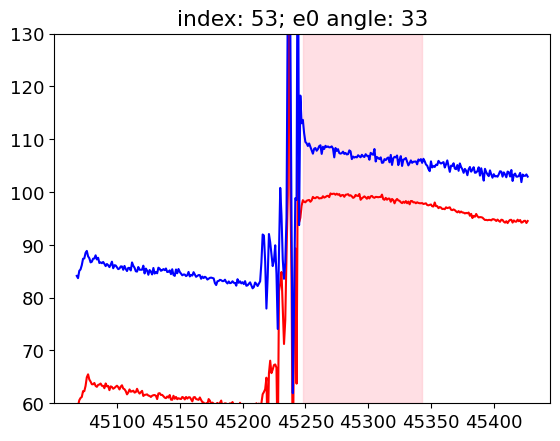

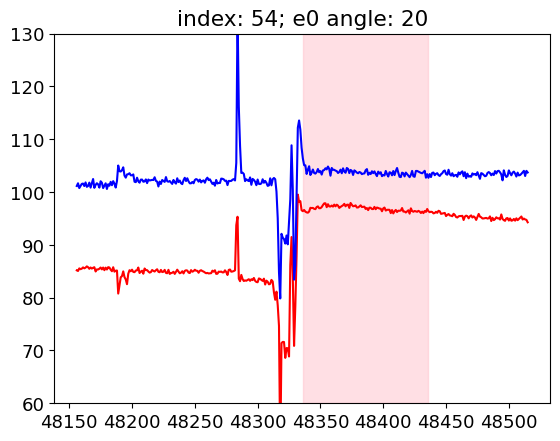

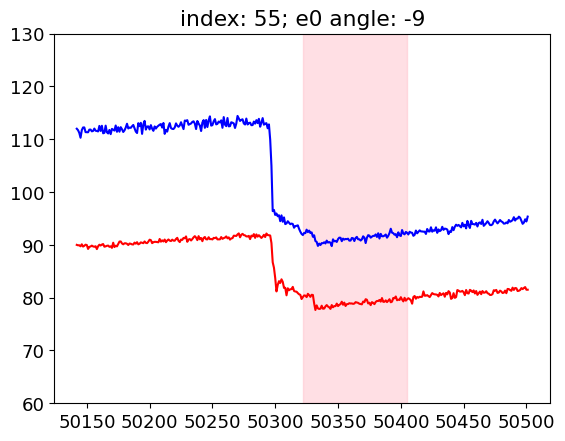

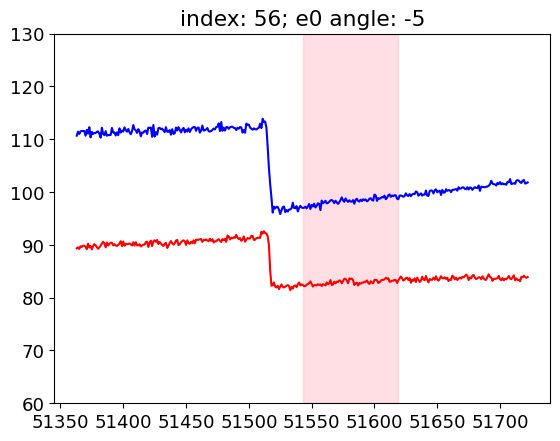

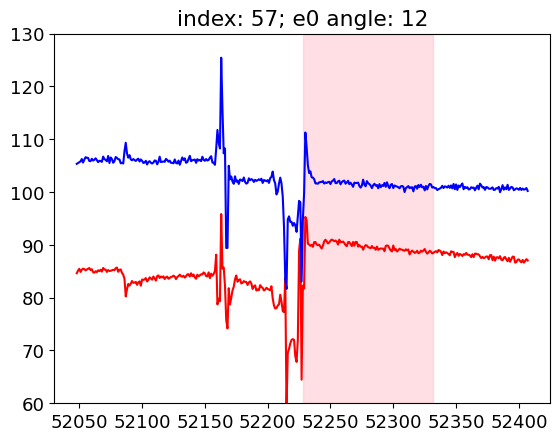

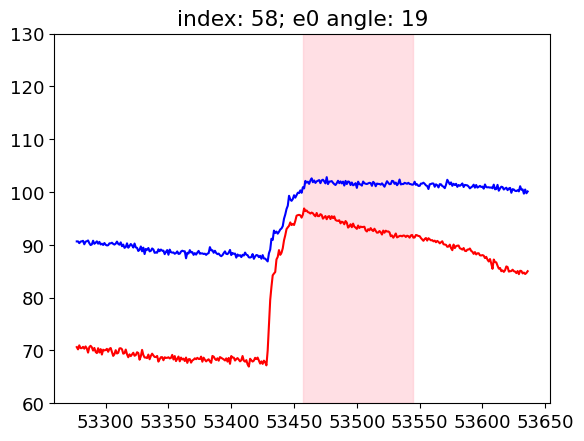

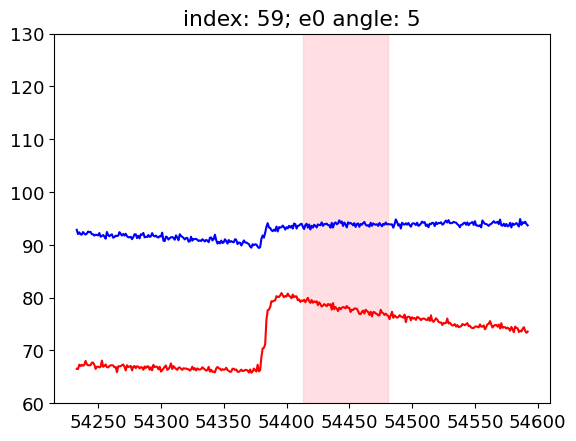

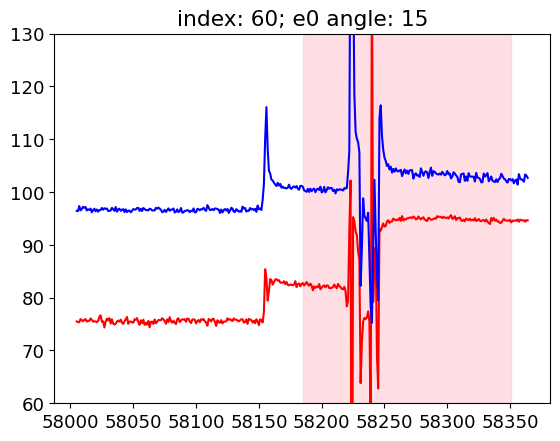

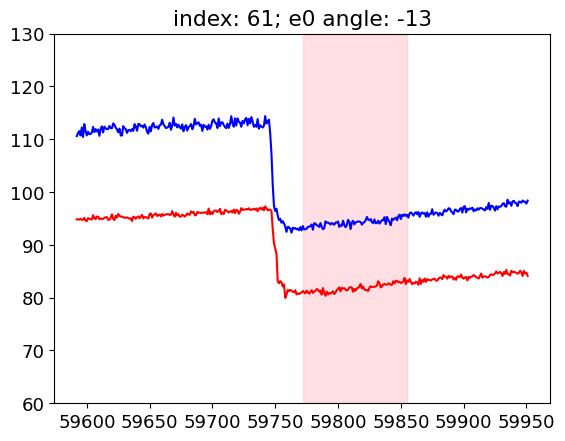

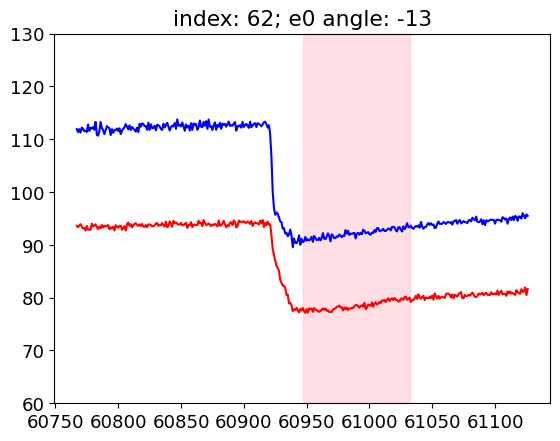

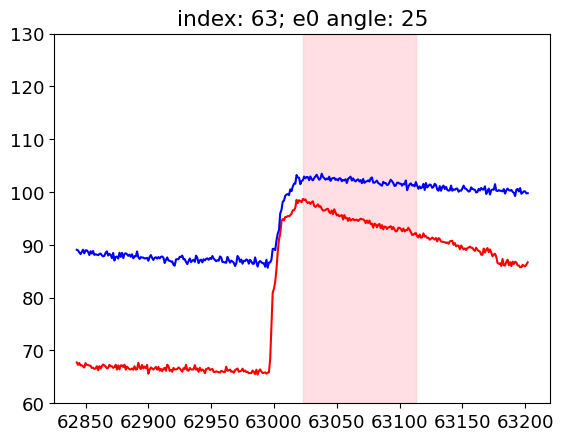

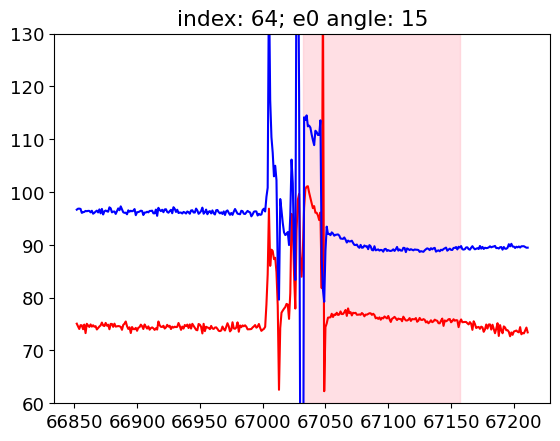

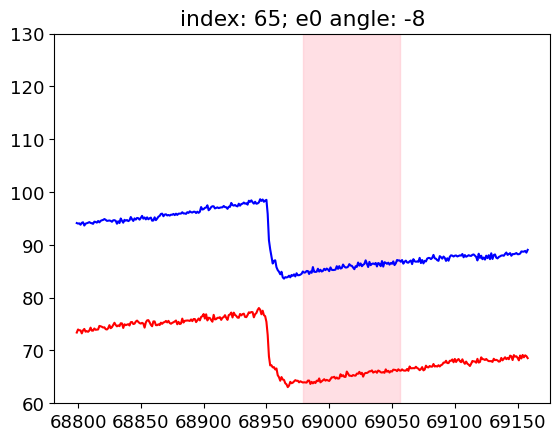

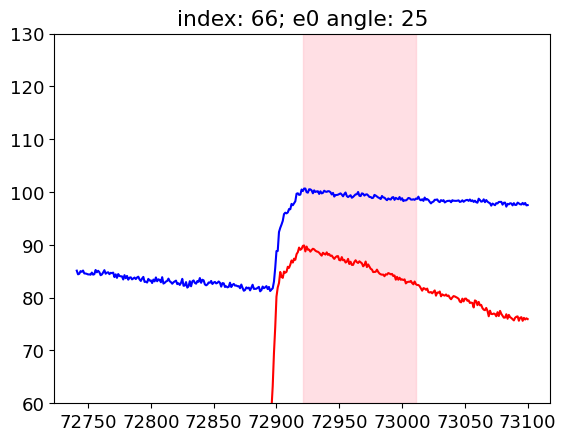

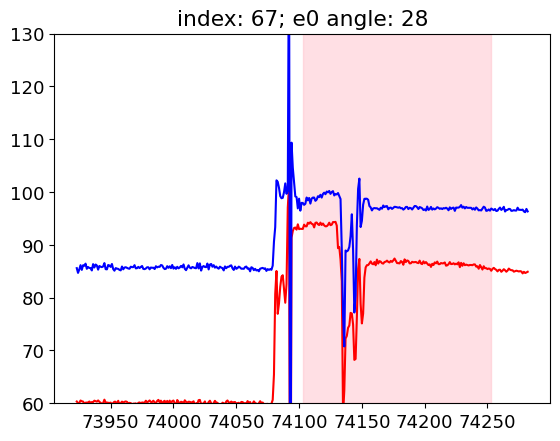

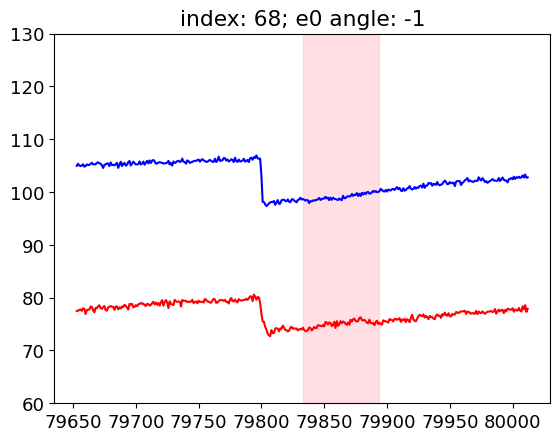

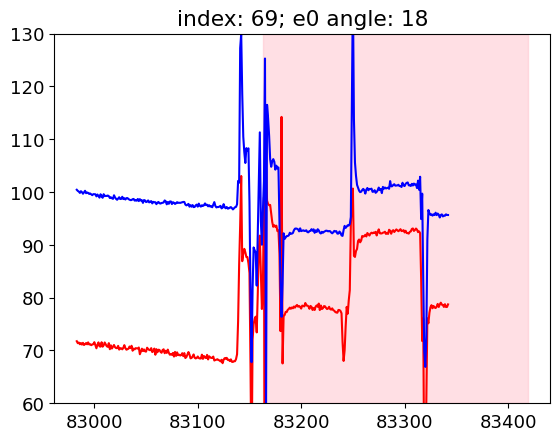

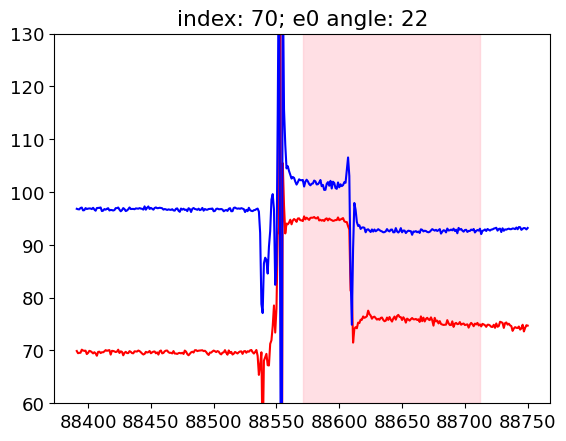

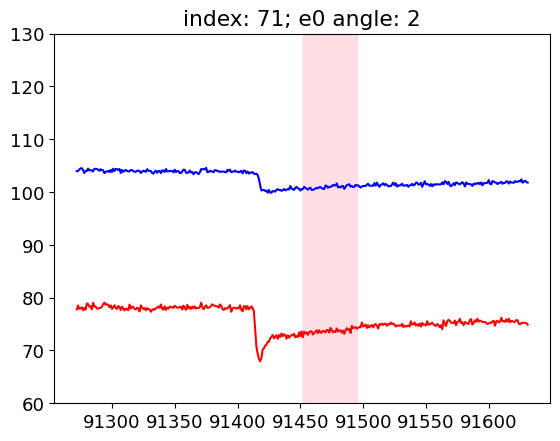

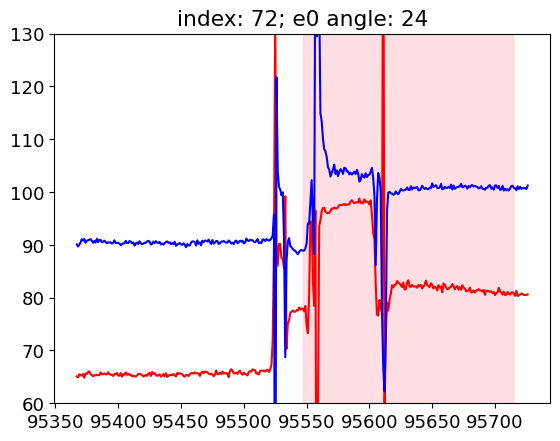

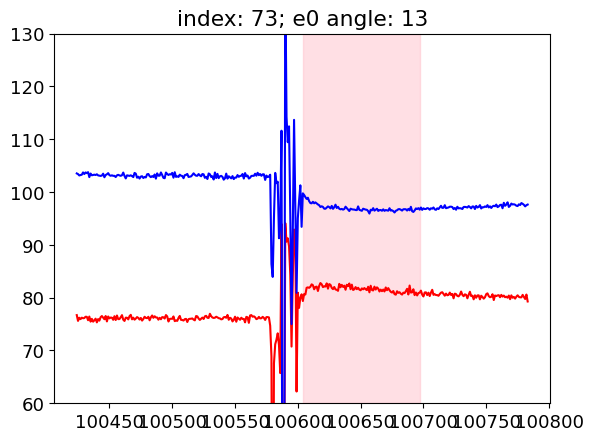

In [101]:
for saccade_index, saccade_row in fish.saccade_df.iterrows():
    fig, ax = plt.subplots(1, 1, dpi = 100)
    saccade_tuples_eyeindex = saccade_row.cont_tuples_eyeindex
    #showing about 4 second of traces
    if saccade_tuples_eyeindex[0] < 180:
        extend_tuples = (0, 360)
    elif saccade_tuples_eyeindex[1] + 180 > len(fish.eye_df):
        extend_tuples = (saccade_tuples_eyeindex[0] - 180, len(fish.eye_df) - 1)
    else:
        extend_tuples = (saccade_tuples_eyeindex[0] - 180, saccade_tuples_eyeindex[0] + 180)
    smalleye_df = fish.eye_df.iloc[extend_tuples[0]:extend_tuples[1]]
    ax.plot(smalleye_df.th_e0, color = 'red')
    ax.plot(smalleye_df.th_e1, color = 'blue')
    ax.set_ylim([60, 130])
    ax.axvspan(saccade_tuples_eyeindex[0], saccade_tuples_eyeindex[1], alpha = 0.5, color = 'pink')
    ax.set_title(f"index: {saccade_index}; e0 angle: {int(saccade_row.e0_change)}")
    plt.show()
    plt.close()

In [87]:
plt.close()

In [102]:
badlist = [0, 9, 20, 23, 24, 29, 47, 57, 64, 69, 72, 73]

In [103]:
#drop bad tracking
proofread_saccade_df = fish.saccade_df.copy().drop(index = badlist)
proofread_saccade_df

,cont_tuples_eyeindex,cont_tuples_realtime_s,e0_change,e1_change,eye_stimuli,eye_realstimuli,eye_fromstart_s,e_conv_change,e_conj_change
1,"(355, 439)","(3.22537, 4.29052)",19.866500,7.906393,right,stationary,3.225370,-11.960107,27.772892
2,"(1026, 1102)","(11.509211, 12.431744)",-7.731388,-5.837915,right,right,11.509211,1.893473,-13.569304
3,"(1403, 1474)","(15.995211, 16.894804)",-4.035882,-5.721512,right,right,15.995211,-1.685630,-9.757394
4,"(2025, 2104)","(23.503128, 24.54534)",-6.045052,-9.755743,right,right,23.503128,-3.710691,-15.800795
5,"(3004, 3078)","(36.050566, 37.105742)",-4.661799,-7.952016,right,right,36.050566,-3.290218,-12.613815
...,...,...,...,...,...,...,...,...,...
66,"(72921, 73011)","(900.33268, 901.376888)",25.074381,16.591414,left,left,19.208618,-8.482967,41.665795
67,"(74103, 74253)","(914.324254, 916.179292)",28.395216,9.659671,left,left,33.200192,-18.735545,38.054887
68,"(79833, 79894)","(978.374923, 979.052111)",-1.647439,-2.115184,right,right,17.117212,-0.467745,-3.762624
70,"(88571, 88712)","(1079.480473, 1081.202868)",22.994832,11.640656,dot_r,dot_r,18.090607,-11.354176,34.635488


In [104]:
proofread_saccade_df.to_csv(fish.path + '//eye//proofread_eye_saccade_df.csv')